In [2]:
!pip install pandas 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 962.0 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 11.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 17.4 MB/s eta 0:00:0000:0100:01


In [6]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.6 MB/s eta 0:00:00a 0:00:01


In [23]:
!pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 14.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 16.6 MB/s eta 0:00:0000:0100:01


In [25]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 6.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 16.5 MB/s eta 0:00:00


In [27]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error


warnings.filterwarnings("ignore")


# =========================
# 1. Пути
# =========================

csv_path = Path.cwd() / "dataset" / "demand_primary_training_minimal.csv"

out_forecast = Path.cwd() / "dataset" / "sarimax_forecast_2025_fixed.csv"
out_metrics = Path.cwd() / "dataset" / "sarimax_metrics_2025_fixed.csv"


# =========================
# 2. Загрузка
# =========================

df = pd.read_csv(csv_path)

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")

df = df.sort_values(["product_name", "period"])

target_col = "target_demand_index"


# =========================
# 3. Настройки
# =========================

train_end = pd.Period("2024Q4", freq="Q")
forecast_end = pd.Period("2025Q4", freq="Q")

order = (1, 1, 1)
seasonal_order = (1, 0, 1, 4)

min_observations = 12

partial_products = [
    "Бензины автомобильные",
    "Газовое моторное топливо",
    "Дизельное топливо",
]


# =========================
# 4. Метрики
# =========================

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


def fit_sarimax(y):
    model = SARIMAX(
        y,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    return model.fit(disp=False)


def period_end_date(period):
    return period.to_timestamp(how="end").normalize()


# =========================
# 5. Обучение и прогноз
# =========================

forecast_rows = []
metrics_rows = []

for product_name, product_df in df.groupby("product_name"):

    product_df = product_df.sort_values("period").copy()

    y_all = (
        product_df
        .set_index("period")[target_col]
        .astype(float)
        .sort_index()
    )

    # Для обучения не берем 2025 год
    y_train_raw = y_all[y_all.index <= train_end].dropna()

    if len(y_train_raw) < min_observations:
        print(f"Пропуск: {product_name} — мало наблюдений: {len(y_train_raw)}")
        continue

    first_train_period = y_train_raw.index.min()
    last_train_period = y_train_raw.index.max()

    # Для обычных товаров прогнозируем строго 2025Q1–2025Q4.
    # Для бензина/дизеля/газа прогнозируем от последнего заполненного квартала до 2025Q4.
    if product_name in partial_products:
        forecast_start = last_train_period + 1
    else:
        forecast_start = pd.Period("2025Q1", freq="Q")

    if forecast_start > forecast_end:
        continue

    forecast_periods = pd.period_range(
        forecast_start,
        forecast_end,
        freq="Q"
    )

    steps = len(forecast_periods)

    # Важно:
    # SARIMAX должен видеть квартальную сетку.
    # Если внутри ряда есть пропущенные кварталы, оставляем их как NaN.
    # Так модель не будет считать 2021Q4 и 2024Q1 соседними кварталами.
    full_train_periods = pd.period_range(
        first_train_period,
        last_train_period,
        freq="Q"
    )

    y_train = y_train_raw.reindex(full_train_periods)

    # =========================
    # Backtest
    # =========================

    bt_mae = np.nan
    bt_rmse = np.nan
    bt_mape = np.nan
    bt_wape = np.nan

    y_observed = y_train_raw.dropna()

    if len(y_observed) >= min_observations + 4:

        backtest_test_periods = y_observed.index[-4:]
        backtest_train_end = backtest_test_periods[0] - 1

        y_bt_train_raw = y_train_raw[y_train_raw.index <= backtest_train_end]
        y_bt_test = y_train_raw[y_train_raw.index.isin(backtest_test_periods)]

        if len(y_bt_train_raw.dropna()) >= min_observations and len(y_bt_test.dropna()) == 4:

            bt_full_periods = pd.period_range(
                y_bt_train_raw.index.min(),
                y_bt_train_raw.index.max(),
                freq="Q"
            )

            y_bt_train = y_bt_train_raw.reindex(bt_full_periods)

            try:
                fitted_bt = fit_sarimax(y_bt_train)

                bt_steps = len(
                    pd.period_range(
                        y_bt_train.index.max() + 1,
                        y_bt_test.index.max(),
                        freq="Q"
                    )
                )

                bt_pred_all = fitted_bt.forecast(steps=bt_steps)

                bt_forecast_periods = pd.period_range(
                    y_bt_train.index.max() + 1,
                    y_bt_test.index.max(),
                    freq="Q"
                )

                bt_pred = pd.Series(
                    np.asarray(bt_pred_all),
                    index=bt_forecast_periods
                ).reindex(y_bt_test.index)

                bt_mae = mean_absolute_error(y_bt_test.values, bt_pred.values)
                bt_rmse = rmse(y_bt_test.values, bt_pred.values)
                bt_mape = mape(y_bt_test.values, bt_pred.values)
                bt_wape = wape(y_bt_test.values, bt_pred.values)

            except Exception as e:
                print(f"Backtest ошибка: {product_name}: {e}")

    # =========================
    # Финальная модель
    # =========================

    try:
        fitted = fit_sarimax(y_train)

        forecast_result = fitted.get_forecast(steps=steps)

        forecast_mean = np.asarray(forecast_result.predicted_mean)
        forecast_ci = forecast_result.conf_int()
        forecast_ci = np.asarray(forecast_ci)

        for i, period in enumerate(forecast_periods):

            actual_value = (
                y_all.loc[period]
                if period in y_all.index and pd.notna(y_all.loc[period])
                else np.nan
            )

            forecast_rows.append({
                "product_name": product_name,
                "period": str(period),
                "period_end": period_end_date(period),
                "first_train_period": str(first_train_period),
                "last_train_period": str(last_train_period),
                "actual_target_demand_index": actual_value,
                "forecast_target_demand_index": forecast_mean[i],
                "forecast_lower": forecast_ci[i, 0],
                "forecast_upper": forecast_ci[i, 1],
                "is_2025_forecast": period.year == 2025,
                "model": "SARIMAX",
                "order": str(order),
                "seasonal_order": str(seasonal_order),
            })

        metrics_rows.append({
            "product_name": product_name,
            "observations_used": int(y_train_raw.notna().sum()),
            "first_train_period": str(first_train_period),
            "last_train_period": str(last_train_period),
            "forecast_start": str(forecast_start),
            "forecast_end": str(forecast_end),
            "backtest_mae": bt_mae,
            "backtest_rmse": bt_rmse,
            "backtest_mape": bt_mape,
            "backtest_wape": bt_wape,
        })

    except Exception as e:
        print(f"Ошибка модели: {product_name}: {e}")


forecast_df = pd.DataFrame(forecast_rows)
metrics_df = pd.DataFrame(metrics_rows)


# =========================
# 6. Метрики по 2025 году, если факт 2025 есть
# =========================

forecast_2025_with_fact = forecast_df[
    (forecast_df["is_2025_forecast"])
    & (forecast_df["actual_target_demand_index"].notna())
].copy()

metrics_2025 = []

for product_name, temp in forecast_2025_with_fact.groupby("product_name"):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    metrics_2025.append({
        "product_name": product_name,
        "test_period": "2025Q1-2025Q4",
        "test_mae_2025": mean_absolute_error(y_true, y_pred),
        "test_rmse_2025": rmse(y_true, y_pred),
        "test_mape_2025": mape(y_true, y_pred),
        "test_wape_2025": wape(y_true, y_pred),
    })

metrics_2025_df = pd.DataFrame(metrics_2025)

metrics_df = metrics_df.merge(
    metrics_2025_df,
    on="product_name",
    how="left"
)


# =========================
# 7. Сохранение
# =========================

forecast_df.to_csv(out_forecast, index=False, encoding="utf-8-sig")
metrics_df.to_csv(out_metrics, index=False, encoding="utf-8-sig")

print("Прогноз сохранен:", out_forecast)
print("Метрики сохранены:", out_metrics)

display(forecast_df.head(30))
display(metrics_df.sort_values("test_wape_2025", na_position="last"))

Прогноз сохранен: /home/senya/projects/diplom/dataset/sarimax_forecast_2025_fixed.csv
Метрики сохранены: /home/senya/projects/diplom/dataset/sarimax_metrics_2025_fixed.csv


,product_name,period,period_end,first_train_period,last_train_period,actual_target_demand_index,forecast_target_demand_index,forecast_lower,forecast_upper,is_2025_forecast,model,order,seasonal_order
0,Автомобили легковые,2025Q1,2025-03-31,2017Q1,2024Q4,133.521054,167.330322,118.557069,216.103575,True,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
1,Автомобили легковые,2025Q2,2025-06-30,2017Q1,2024Q4,144.210737,166.881283,108.214660,225.547905,True,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
2,Автомобили легковые,2025Q3,2025-09-30,2017Q1,2024Q4,182.710840,166.871605,104.037842,229.705368,True,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
3,Автомобили легковые,2025Q4,2025-12-31,2017Q1,2024Q4,181.156470,168.435467,103.595275,233.275658,True,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
4,Бензины автомобильные,2024Q2,2024-06-30,2017Q1,2024Q1,NaN,91.878588,74.390744,109.366432,False,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
5,Бензины автомобильные,2024Q3,2024-09-30,2017Q1,2024Q1,NaN,110.471626,96.163609,124.779643,False,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
6,Бензины автомобильные,2024Q4,2024-12-31,2017Q1,2024Q1,NaN,102.028187,84.422390,119.633984,False,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
7,Бензины автомобильные,2025Q1,2025-03-31,2017Q1,2024Q1,NaN,88.456560,71.924051,104.989070,True,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
8,Бензины автомобильные,2025Q2,2025-06-30,2017Q1,2024Q1,NaN,89.873349,70.561176,109.185521,True,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"
9,Бензины автомобильные,2025Q3,2025-09-30,2017Q1,2024Q1,NaN,107.601147,88.546241,126.656052,True,SARIMAX,"(1, 1, 1)","(1, 0, 1, 4)"


,product_name,observations_used,first_train_period,last_train_period,forecast_start,forecast_end,backtest_mae,backtest_rmse,backtest_mape,backtest_wape,test_period,test_mae_2025,test_rmse_2025,test_mape_2025,test_wape_2025
12,Мясо животных,32,2017Q1,2024Q4,2025Q1,2025Q4,0.605195,0.606441,0.585986,0.585193,2025Q1-2025Q4,2.838877,3.207804,2.748243,2.772215
6,Макаронные изделия,32,2017Q1,2024Q4,2025Q1,2025Q4,4.655821,4.764292,4.105441,4.067970,2025Q1-2025Q4,4.185623,5.567492,3.788656,3.572936
11,Мясо домашней птицы,32,2017Q1,2024Q4,2025Q1,2025Q4,2.804844,3.330465,2.216722,2.310100,2025Q1-2025Q4,4.231425,4.344535,3.559173,3.576019
10,Мука,32,2017Q1,2024Q4,2025Q1,2025Q4,5.536746,7.137203,5.197850,5.406359,2025Q1-2025Q4,4.443382,5.927461,3.996835,4.250633
18,сыры,32,2017Q1,2024Q4,2025Q1,2025Q4,4.680698,6.440573,4.116694,3.767984,2025Q1-2025Q4,9.454318,12.874012,6.254342,6.877972
8,Молоко питьевое,32,2017Q1,2024Q4,2025Q1,2025Q4,4.842911,5.597605,4.015442,3.970349,2025Q1-2025Q4,9.437369,10.133575,6.957592,7.062500
13,Свежие овощи,32,2017Q1,2024Q4,2025Q1,2025Q4,13.320057,13.600367,9.226148,9.235510,2025Q1-2025Q4,9.964878,11.230284,7.390054,7.143627
17,Чай,32,2017Q1,2024Q4,2025Q1,2025Q4,3.475702,4.041513,3.711638,3.435859,2025Q1-2025Q4,7.177724,7.897193,7.762018,7.449600
14,Свежие фрукты,32,2017Q1,2024Q4,2025Q1,2025Q4,9.402520,10.491468,7.186186,6.988967,2025Q1-2025Q4,10.657261,12.356110,9.138318,8.415442
7,Маргариновая продукция,32,2017Q1,2024Q4,2025Q1,2025Q4,9.247979,9.311156,11.166912,11.030278,2025Q1-2025Q4,9.761193,10.048001,12.198289,11.957993


In [28]:
forecast_df[
    ["product_name", "period", "last_train_period", "forecast_target_demand_index"]
].head(20)

,product_name,period,last_train_period,forecast_target_demand_index
0,Автомобили легковые,2025Q1,2024Q4,167.330322
1,Автомобили легковые,2025Q2,2024Q4,166.881283
2,Автомобили легковые,2025Q3,2024Q4,166.871605
3,Автомобили легковые,2025Q4,2024Q4,168.435467
4,Бензины автомобильные,2024Q2,2024Q1,91.878588
5,Бензины автомобильные,2024Q3,2024Q1,110.471626
6,Бензины автомобильные,2024Q4,2024Q1,102.028187
7,Бензины автомобильные,2025Q1,2024Q1,88.456560
8,Бензины автомобильные,2025Q2,2024Q1,89.873349
9,Бензины автомобильные,2025Q3,2024Q1,107.601147


Физический объем добавлен.
Заполненность: 99.5 %
Товаров для построения графиков: 19


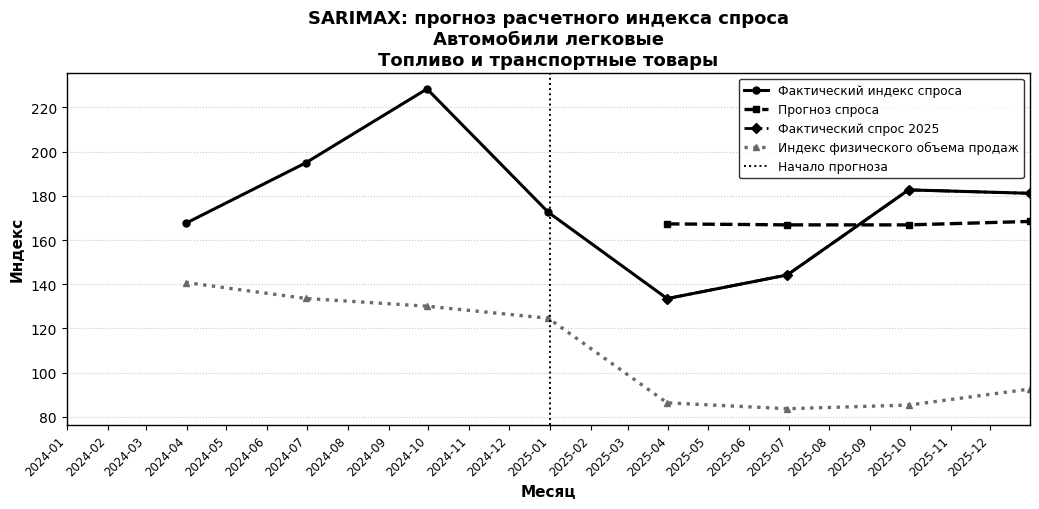

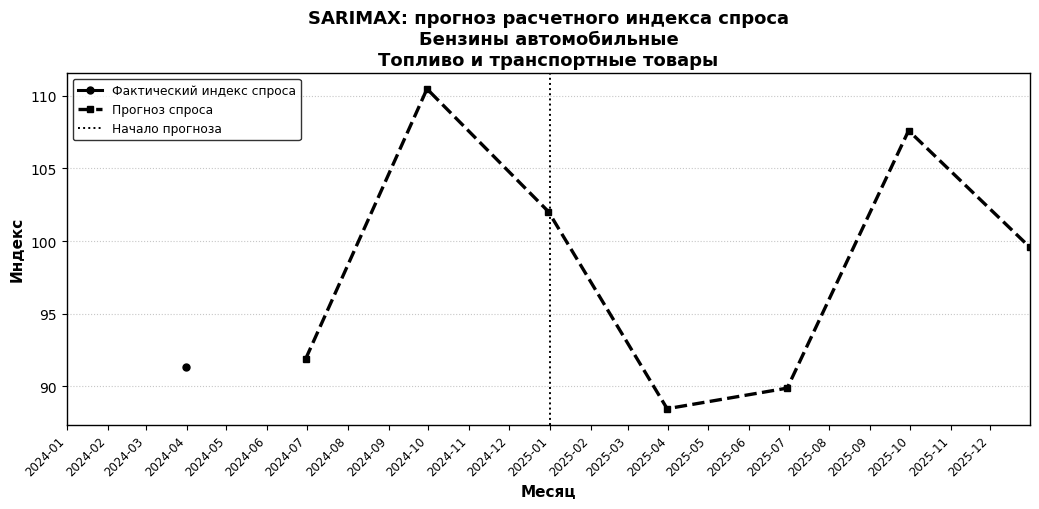

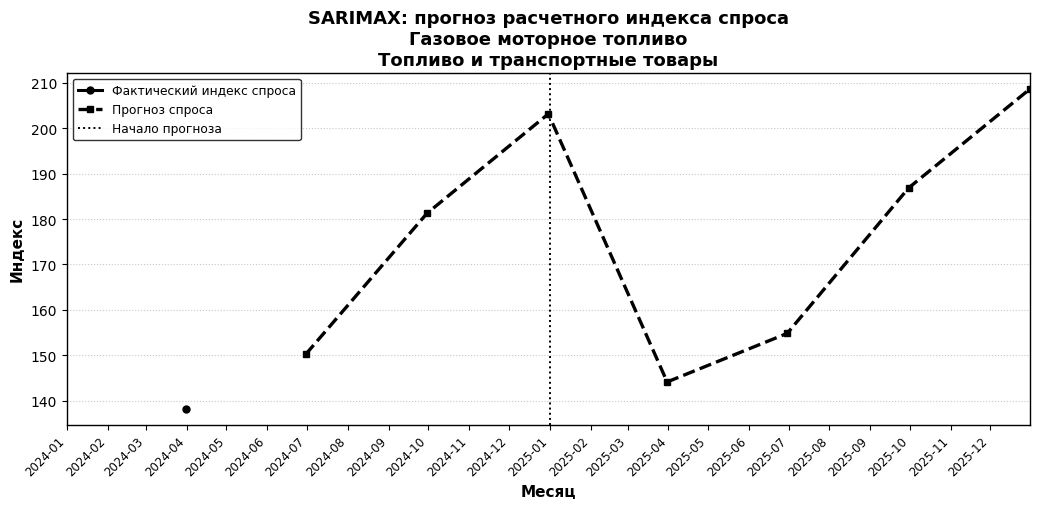

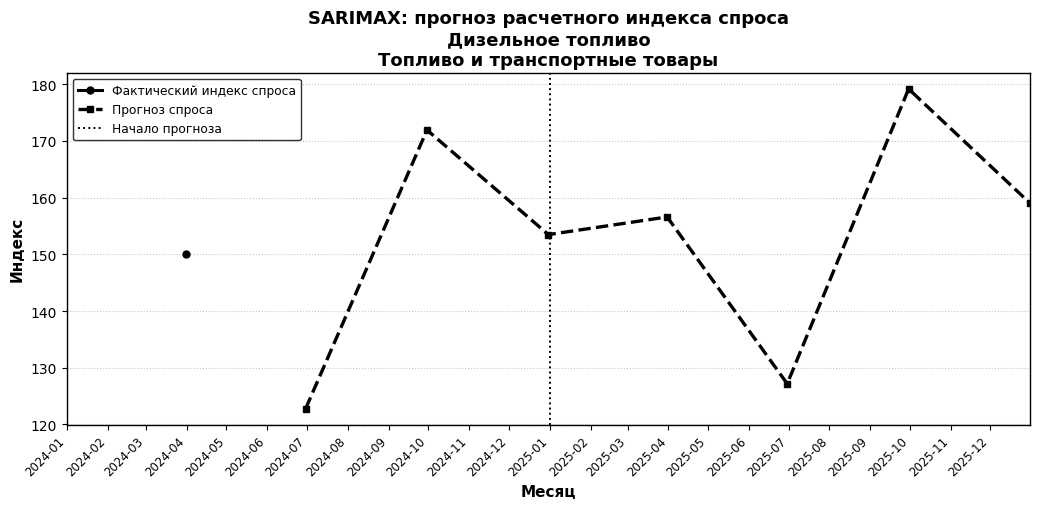

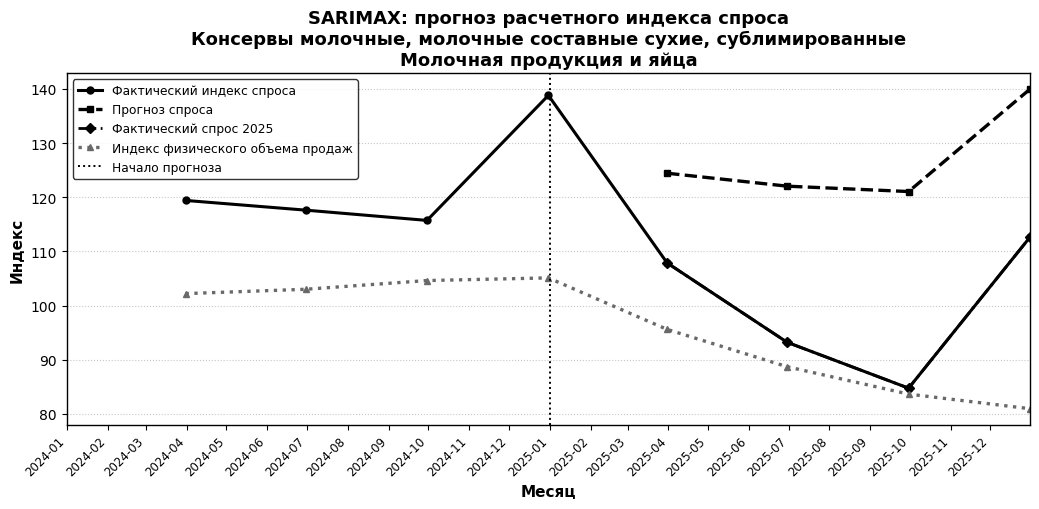

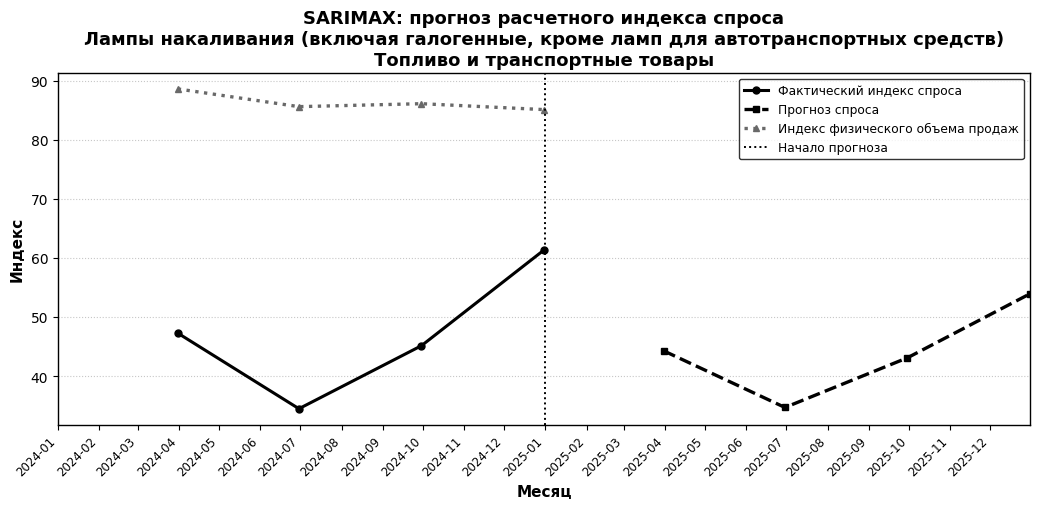

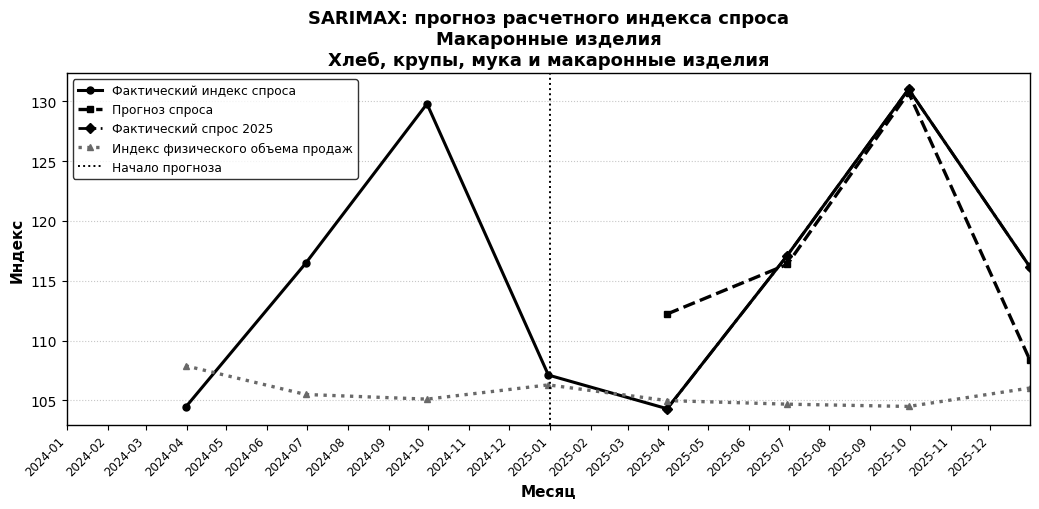

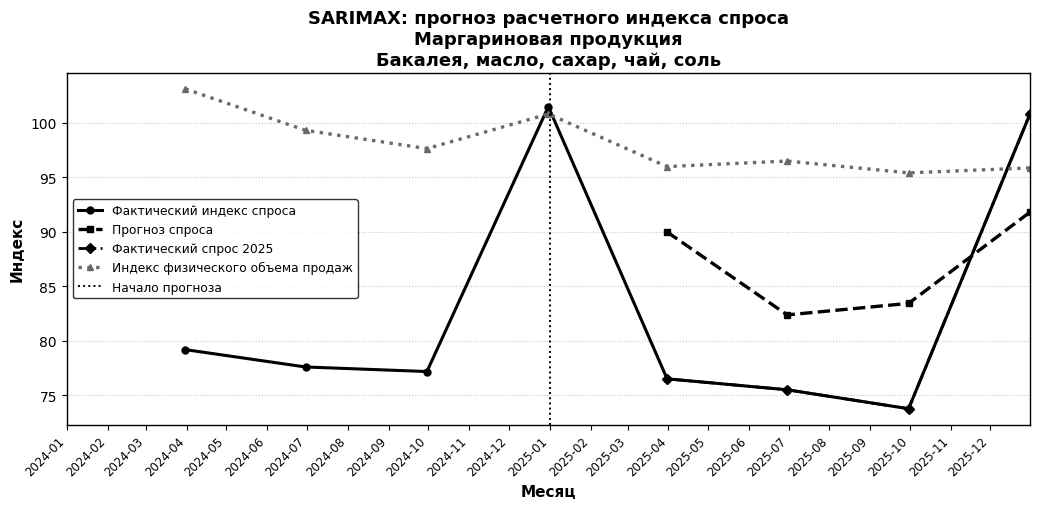

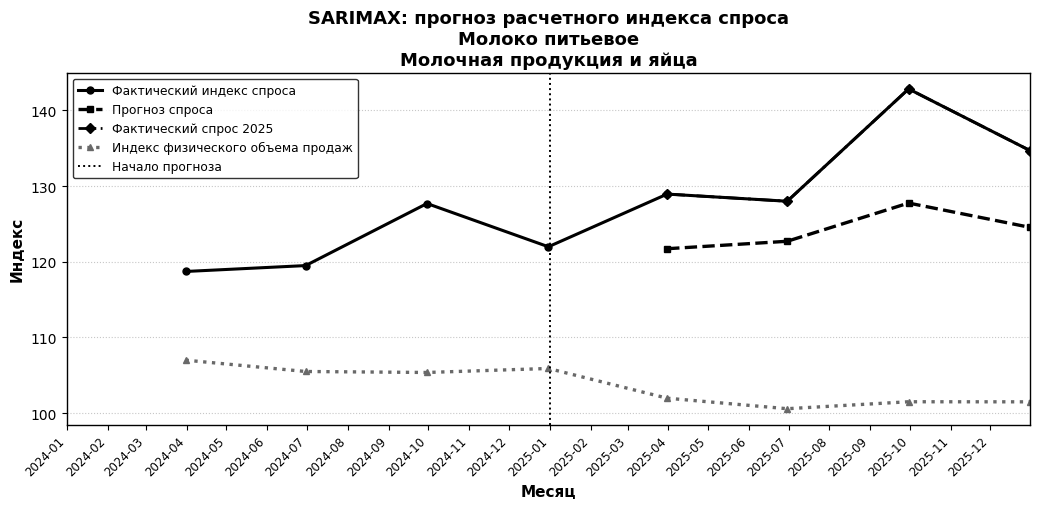

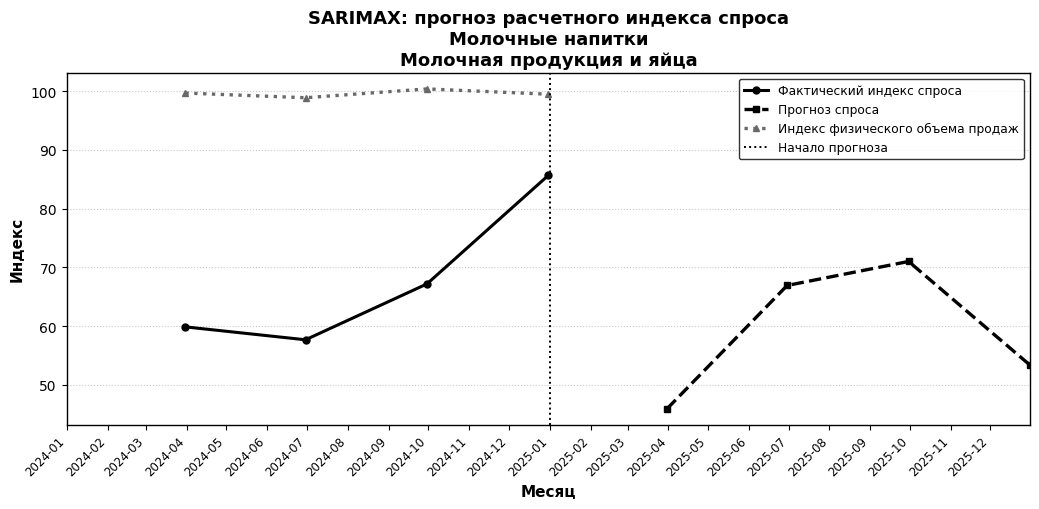

Графики сохранены в папку: /home/senya/projects/diplom/dataset/plots_demand_forecast_vs_physical_volume


In [34]:
# ============================================================
# ЧБ-графики:
# прогноз расчетного индекса спроса + индекс физического объема продаж
# Период: 2024–2025
# Ось X — месячная шкала
# ============================================================

from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. Настройки путей
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"
CSV_DIR = DATASET_DIR / "csv"

DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"
FORECAST_PATH = DATASET_DIR / "sarimax_forecast_2025_fixed.csv"
PHYSICAL_PATH = CSV_DIR / "physical_volume_product_quarterly.csv"

PLOTS_DIR = DATASET_DIR / "plots_demand_forecast_vs_physical_volume"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Настройки отображения
# ============================================================

SHOW_ALL_GRAPHS = True   # True — показать все графики
SHOW_FIRST_N = 10         # если SHOW_ALL_GRAPHS=False, показать первые N

FORECAST_START = pd.Timestamp("2025-01-01")

TARGET_COL = "target_demand_index"
PHYSICAL_VOLUME_COL = "physical_volume_cumulative_yoy_index"

PRODUCT_ID_COL = "product_code"
PRODUCT_NAME_COL = "product_name"


# ============================================================
# 3. Загрузка основного датасета
# ============================================================

work = pd.read_csv(DATA_PATH)

work["period_end"] = pd.to_datetime(work["period_end"])
work["period"] = work["period_end"].dt.to_period("Q").astype(str)

# На случай, если в датасете старые названия колонок
work = work.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})


# ============================================================
# 4. Загрузка прогноза SARIMAX
# ============================================================

forecast_df = pd.read_csv(FORECAST_PATH)

forecast_df["period_end"] = pd.to_datetime(forecast_df["period_end"])
forecast_df["period"] = forecast_df["period"].astype(str)

forecast_df = forecast_df.rename(columns={
    "Код товара": "product_code",
    "Название товара": "product_name",
    "Период": "period_end",
    "Прогноз спроса 2025": "forecast_target_demand_index",
    "Фактический спрос 2025": "actual_target_demand_index",
})

# Если в прогнозе нет product_code, подтягиваем его из основного датасета
if PRODUCT_ID_COL not in forecast_df.columns:
    product_map = (
        work[[PRODUCT_ID_COL, PRODUCT_NAME_COL]]
        .drop_duplicates()
    )

    forecast_df = forecast_df.merge(
        product_map,
        on=PRODUCT_NAME_COL,
        how="left"
    )


# ============================================================
# 5. Загрузка индекса физического объема продаж
# ============================================================

physical = pd.read_csv(PHYSICAL_PATH)

physical["period_end"] = pd.to_datetime(physical["period_end"])
physical["period"] = physical["period_end"].dt.to_period("Q").astype(str)

physical = physical.rename(columns={
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

# Оставляем только нужные колонки
physical = physical[
    [
        PRODUCT_NAME_COL,
        "period",
        PHYSICAL_VOLUME_COL,
    ]
].copy()

# Если по товару и кварталу несколько строк, берем среднее
physical = (
    physical
    .groupby([PRODUCT_NAME_COL, "period"], as_index=False)[PHYSICAL_VOLUME_COL]
    .mean()
)

# На всякий случай удаляем старую колонку, если она уже была
work = work.drop(columns=[PHYSICAL_VOLUME_COL], errors="ignore")

# Объединяем по названию товара и кварталу
work = work.merge(
    physical,
    on=[PRODUCT_NAME_COL, "period"],
    how="left"
)

print("Физический объем добавлен.")
print(
    "Заполненность:",
    round(work[PHYSICAL_VOLUME_COL].notna().mean() * 100, 1),
    "%"
)


# ============================================================
# 6. Проверка нужных колонок
# ============================================================

required_work_cols = [
    "period_end",
    "period",
    PRODUCT_ID_COL,
    PRODUCT_NAME_COL,
    TARGET_COL,
    PHYSICAL_VOLUME_COL,
]

required_forecast_cols = [
    "period_end",
    "period",
    PRODUCT_NAME_COL,
    "forecast_target_demand_index",
]

missing_work_cols = [col for col in required_work_cols if col not in work.columns]
missing_forecast_cols = [col for col in required_forecast_cols if col not in forecast_df.columns]

if missing_work_cols:
    raise ValueError(f"В основном датасете не хватает колонок: {missing_work_cols}")

if missing_forecast_cols:
    raise ValueError(f"В прогнозе не хватает колонок: {missing_forecast_cols}")


# ============================================================
# 7. Список товаров для построения графиков
# ============================================================

plot_products = (
    forecast_df[PRODUCT_NAME_COL]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Товаров для построения графиков:", len(plot_products))


# ============================================================
# 8. Функция безопасного имени файла
# ============================================================

def make_safe_filename(value):
    value = str(value)
    value = re.sub(r"[^\wа-яА-ЯёЁ\-]+", "_", value)
    value = value.strip("_")
    return value[:120]


# ============================================================
# 9. Построение графиков
# ============================================================

for idx, product_name in enumerate(plot_products, start=1):

    hist = (
        work[work[PRODUCT_NAME_COL] == product_name]
        .sort_values("period_end")
        .copy()
    )

    fc = (
        forecast_df[forecast_df[PRODUCT_NAME_COL] == product_name]
        .sort_values("period_end")
        .copy()
    )

    if hist.empty or fc.empty:
        continue

    product_id = hist[PRODUCT_ID_COL].iloc[0]

    group_name = ""
    if "group_name" in hist.columns and hist["group_name"].notna().any():
        group_name = hist["group_name"].dropna().iloc[0]

    # Фактические данные 2024–2025
    hist_plot = hist[
        (hist["period_end"] >= pd.Timestamp("2024-01-01")) &
        (hist["period_end"] <= pd.Timestamp("2025-12-31"))
    ].copy()

    # Прогноз 2024–2025
    # Для обычных товаров это 2025.
    # Для бензина/дизеля/газа может быть 2024Q2–2025Q4.
    fc_plot = fc[
        (fc["period_end"] >= pd.Timestamp("2024-01-01")) &
        (fc["period_end"] <= pd.Timestamp("2025-12-31"))
    ].copy()

    if hist_plot.empty and fc_plot.empty:
        continue

    fig, ax = plt.subplots(figsize=(10.5, 5.2))

    # --------------------------------------------------------
    # Фактический расчетный индекс спроса
    # --------------------------------------------------------

    hist_fact = hist_plot[hist_plot[TARGET_COL].notna()].copy()

    if not hist_fact.empty:
        ax.plot(
            hist_fact["period_end"],
            hist_fact[TARGET_COL],
            color="black",
            linestyle="-",
            linewidth=2.2,
            marker="o",
            markersize=5,
            label="Фактический индекс спроса"
        )

    # --------------------------------------------------------
    # Прогноз расчетного индекса спроса
    # --------------------------------------------------------

    if not fc_plot.empty:
        ax.plot(
            fc_plot["period_end"],
            fc_plot["forecast_target_demand_index"],
            color="black",
            linestyle="--",
            linewidth=2.4,
            marker="s",
            markersize=5,
            label="Прогноз спроса"
        )

    # --------------------------------------------------------
    # Фактический спрос 2025, если есть в forecast_df
    # --------------------------------------------------------

    if "actual_target_demand_index" in fc_plot.columns:
        actual_2025 = fc_plot[
            fc_plot["actual_target_demand_index"].notna()
        ].copy()

        if not actual_2025.empty:
            ax.plot(
                actual_2025["period_end"],
                actual_2025["actual_target_demand_index"],
                color="black",
                linestyle="-.",
                linewidth=2.0,
                marker="D",
                markersize=5,
                label="Фактический спрос 2025"
            )

    # --------------------------------------------------------
    # Индекс физического объема продаж
    # --------------------------------------------------------

    physical_plot = hist_plot[
        hist_plot[PHYSICAL_VOLUME_COL].notna()
    ].copy()

    if not physical_plot.empty:
        ax.plot(
            physical_plot["period_end"],
            physical_plot[PHYSICAL_VOLUME_COL],
            color="dimgray",
            linestyle=":",
            linewidth=2.4,
            marker="^",
            markersize=5,
            label="Индекс физического объема продаж"
        )

    # --------------------------------------------------------
    # Вертикальная линия начала прогноза
    # --------------------------------------------------------

    ax.axvline(
        FORECAST_START,
        color="black",
        linestyle=":",
        linewidth=1.4,
        label="Начало прогноза"
    )

    # --------------------------------------------------------
    # Заголовок и подписи
    # --------------------------------------------------------

    title = (
        "SARIMAX: прогноз расчетного индекса спроса\n"
        f"{product_name}"
    )

    if group_name:
        title += f"\n{group_name}"

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Месяц", fontsize=11, fontweight="bold")
    ax.set_ylabel("Индекс", fontsize=11, fontweight="bold")

    # --------------------------------------------------------
    # Ось X — месячная шкала
    # --------------------------------------------------------

    ax.set_xlim(
        pd.Timestamp("2024-01-01"),
        pd.Timestamp("2025-12-31")
    )

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        fontsize=8.5
    )

    # --------------------------------------------------------
    # Сетка и рамка
    # --------------------------------------------------------

    ax.grid(
        True,
        axis="y",
        linestyle=":",
        linewidth=0.8,
        alpha=0.7
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color("black")

    ax.legend(
        fontsize=8.8,
        frameon=True,
        edgecolor="black",
        loc="best"
    )

    plt.tight_layout()

    safe_id = make_safe_filename(product_id)
    out_path = PLOTS_DIR / f"sarimax_demand_forecast_physical_volume_2024_2025_{safe_id}.png"

    plt.savefig(
        out_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    if SHOW_ALL_GRAPHS or idx <= SHOW_FIRST_N:
        plt.show()
    else:
        plt.close(fig)


print("Графики сохранены в папку:", PLOTS_DIR)

In [41]:
from pathlib import Path
import numpy as np
import pandas as pd


# ============================================================
# 1. Пути и загрузка
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"
FORECAST_PATH = DATASET_DIR / "sarimax_forecast_2025_fixed.csv"

df = pd.read_csv(DATA_PATH)
forecast_df = pd.read_csv(FORECAST_PATH)


# ============================================================
# 2. Подготовка колонок
# ============================================================

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q").astype(str)

forecast_df["period_end"] = pd.to_datetime(forecast_df["period_end"])
forecast_df["period"] = forecast_df["period"].astype(str)

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

forecast_df = forecast_df.rename(columns={
    "Код товара": "product_code",
    "Название товара": "product_name",
    "Прогноз спроса 2025": "forecast_target_demand_index",
    "Фактический спрос 2025": "actual_target_demand_index",
})


# ============================================================
# 3. Подтягиваем категорию товара в прогноз
# ============================================================

product_group_map = (
    df[["product_name", "group_code", "group_name"]]
    .drop_duplicates()
)

forecast_with_group = forecast_df.merge(
    product_group_map,
    on="product_name",
    how="left"
)


# ============================================================
# 4. Оставляем только 2025 год и строки, где есть факт
# ============================================================

forecast_2025 = forecast_with_group[
    (forecast_with_group["period"].str.startswith("2025"))
    & (forecast_with_group["actual_target_demand_index"].notna())
    & (forecast_with_group["forecast_target_demand_index"].notna())
].copy()


# ============================================================
# 5. Функции метрик
# ============================================================

def calc_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def calc_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(y_true - y_pred)) / denominator * 100


# ============================================================
# 6. Ошибки по категориям
# ============================================================

category_errors = []

for (group_code, group_name), temp in forecast_2025.groupby(["group_code", "group_name"]):

    y_true = temp["actual_target_demand_index"].values
    y_pred = temp["forecast_target_demand_index"].values

    category_errors.append({
        "group_code": group_code,
        "group_name": group_name,
        "products_count": temp["product_name"].nunique(),
        "observations_count": len(temp),
        "actual_mean": np.mean(y_true),
        "forecast_mean": np.mean(y_pred),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": calc_rmse(y_true, y_pred),
        "MAPE_%": calc_mape(y_true, y_pred),
        "WAPE_%": calc_wape(y_true, y_pred),
    })

category_errors_df = (
    pd.DataFrame(category_errors)
    .sort_values("WAPE_%")
    .reset_index(drop=True)
)

display(category_errors_df)

,group_code,group_name,products_count,observations_count,actual_mean,forecast_mean,MAE,RMSE,MAPE_%,WAPE_%
0,G03,"Мясо, птица, рыба и колбасные изделия",2,8,110.366225,112.736412,3.535151,3.818703,3.153708,3.203109
1,G01,"Хлеб, крупы, мука и макаронные изделия",2,8,110.841286,110.271742,4.314502,5.750294,3.892746,3.892505
2,G05,"Бакалея, масло, сахар, чай, соль",2,8,88.989749,95.204013,8.469459,9.036813,9.980153,9.517342
3,G04,"Овощи, фрукты и картофель",3,12,143.771203,139.289669,14.836166,17.930120,10.391519,10.319289
4,G02,Молочная продукция и яйца,3,12,123.564304,127.040138,15.381340,18.803887,13.851872,12.448045
5,G10,Топливо и транспортные товары,1,4,160.399775,167.379669,21.260013,22.747118,14.183214,13.254391
6,G07,"Товары для дома, гигиены и бытовая химия",1,4,124.640157,160.680202,36.040046,36.273005,29.055694,28.915276


In [42]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. Подготовка данных для диагностики ошибок 2025
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"

DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"
FORECAST_PATH = DATASET_DIR / "sarimax_forecast_2025_fixed.csv"

df = pd.read_csv(DATA_PATH)
forecast_df = pd.read_csv(FORECAST_PATH)

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q").astype(str)

forecast_df["period_end"] = pd.to_datetime(forecast_df["period_end"])
forecast_df["period"] = forecast_df["period"].astype(str)

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

forecast_df = forecast_df.rename(columns={
    "Код товара": "product_code",
    "Название товара": "product_name",
    "Прогноз спроса 2025": "forecast_target_demand_index",
    "Фактический спрос 2025": "actual_target_demand_index",
})

product_group_map = (
    df[["product_name", "group_code", "group_name"]]
    .drop_duplicates()
)

diagnostic = forecast_df.merge(
    product_group_map,
    on="product_name",
    how="left"
)

diagnostic = diagnostic[
    diagnostic["period"].str.startswith("2025")
].copy()

diagnostic = diagnostic[
    diagnostic["actual_target_demand_index"].notna()
    & diagnostic["forecast_target_demand_index"].notna()
].copy()

diagnostic["error"] = (
    diagnostic["forecast_target_demand_index"]
    - diagnostic["actual_target_demand_index"]
)

diagnostic["abs_error"] = diagnostic["error"].abs()

diagnostic["ape_%"] = (
    diagnostic["abs_error"]
    / diagnostic["actual_target_demand_index"].abs()
    * 100
)

diagnostic["direction"] = np.where(
    diagnostic["error"] > 0,
    "завышение прогноза",
    "занижение прогноза"
)

diagnostic = diagnostic.sort_values(
    ["group_code", "product_name", "period"]
)

diagnostic[
    [
        "group_code",
        "group_name",
        "product_name",
        "period",
        "actual_target_demand_index",
        "forecast_target_demand_index",
        "error",
        "abs_error",
        "ape_%",
        "direction",
    ]
]

,group_code,group_name,product_name,period,actual_target_demand_index,forecast_target_demand_index,error,abs_error,ape_%,direction
33,G01,"Хлеб, крупы, мука и макаронные изделия",Макаронные изделия,2025Q1,104.309186,112.226273,7.917087,7.917087,7.590019,завышение прогноза
34,G01,"Хлеб, крупы, мука и макаронные изделия",Макаронные изделия,2025Q2,117.114583,116.371423,-0.743160,0.743160,0.634558,занижение прогноза
35,G01,"Хлеб, крупы, мука и макаронные изделия",Макаронные изделия,2025Q3,131.022371,130.729180,-0.293191,0.293191,0.223771,занижение прогноза
36,G01,"Хлеб, крупы, мука и макаронные изделия",Макаронные изделия,2025Q4,116.145760,108.356706,-7.789054,7.789054,6.706275,занижение прогноза
49,G01,"Хлеб, крупы, мука и макаронные изделия",Мука,2025Q1,98.544241,99.343810,0.799569,0.799569,0.811381,завышение прогноза
50,G01,"Хлеб, крупы, мука и макаронные изделия",Мука,2025Q2,91.355099,96.154823,4.799724,4.799724,5.253920,завышение прогноза
51,G01,"Хлеб, крупы, мука и макаронные изделия",Мука,2025Q3,102.051877,103.515331,1.463454,1.463454,1.434029,завышение прогноза
52,G01,"Хлеб, крупы, мука и макаронные изделия",Мука,2025Q4,126.187170,115.476389,-10.710781,10.710781,8.488011,занижение прогноза
25,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q1,107.860824,124.422215,16.561391,16.561391,15.354408,завышение прогноза
26,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q2,93.206196,122.032062,28.825866,28.825866,30.926985,завышение прогноза


In [43]:
# ============================================================
# 2. Вклад товаров в ошибку категории
# ============================================================

product_error_diagnostic = (
    diagnostic
    .groupby(["group_code", "group_name", "product_name"], as_index=False)
    .agg(
        observations=("period", "count"),
        actual_mean=("actual_target_demand_index", "mean"),
        forecast_mean=("forecast_target_demand_index", "mean"),
        mean_error=("error", "mean"),
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        mape_percent=("ape_%", "mean"),
        total_abs_error=("abs_error", "sum"),
        total_actual=("actual_target_demand_index", lambda x: x.abs().sum()),
    )
)

product_error_diagnostic["wape_percent"] = (
    product_error_diagnostic["total_abs_error"]
    / product_error_diagnostic["total_actual"]
    * 100
)

# вклад товара в суммарную ошибку своей категории
category_abs_error = (
    product_error_diagnostic
    .groupby(["group_code", "group_name"])["total_abs_error"]
    .sum()
    .reset_index(name="category_total_abs_error")
)

product_error_diagnostic = product_error_diagnostic.merge(
    category_abs_error,
    on=["group_code", "group_name"],
    how="left"
)

product_error_diagnostic["share_of_category_error_%"] = (
    product_error_diagnostic["total_abs_error"]
    / product_error_diagnostic["category_total_abs_error"]
    * 100
)

product_error_diagnostic = product_error_diagnostic.sort_values(
    ["group_code", "share_of_category_error_%"],
    ascending=[True, False]
)

display(product_error_diagnostic)

,group_code,group_name,product_name,observations,actual_mean,forecast_mean,mean_error,mean_abs_error,max_abs_error,mape_percent,total_abs_error,total_actual,wape_percent,category_total_abs_error,share_of_category_error_%
1,G01,"Хлеб, крупы, мука и макаронные изделия",Мука,4,104.534597,103.622588,-0.912009,4.443382,10.710781,3.996835,17.773528,418.138387,4.250633,34.516019,51.493563
0,G01,"Хлеб, крупы, мука и макаронные изделия",Макаронные изделия,4,117.147975,116.920896,-0.227079,4.185623,7.917087,3.788656,16.742491,468.591900,3.572936,34.516019,48.506437
2,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",4,99.608519,126.860852,27.252333,27.252333,36.295540,28.343682,109.009334,398.434074,27.359441,184.576081,59.059296
4,G02,Молочная продукция и яйца,сыры,4,137.457934,130.070472,-7.387462,9.454318,23.383958,6.254342,37.817273,549.831736,6.877972,184.576081,20.488718
3,G02,Молочная продукция и яйца,Молоко питьевое,4,133.626459,124.189091,-9.437369,9.437369,15.084228,6.957592,37.749475,534.505838,7.062500,184.576081,20.451986
5,G03,"Мясо, птица, рыба и колбасные изделия",Мясо домашней птицы,4,118.327815,122.559240,4.231425,4.231425,5.356593,3.559173,16.925699,473.311261,3.576019,28.281207,59.847868
6,G03,"Мясо, птица, рыба и колбасные изделия",Мясо животных,4,102.404635,102.913585,0.508950,2.838877,4.659854,2.748243,11.355507,409.618539,2.772215,28.281207,40.152132
9,G04,"Овощи, фрукты и картофель",Свежий картофель,4,165.181015,141.294657,-23.886358,23.886358,35.646073,14.646184,95.545432,660.724059,14.460716,178.033986,53.666962
8,G04,"Овощи, фрукты и картофель",Свежие фрукты,4,126.639351,135.066433,8.427082,10.657261,19.740141,9.138318,42.629044,506.557402,8.415442,178.033986,23.944329
7,G04,"Овощи, фрукты и картофель",Свежие овощи,4,139.493243,141.507918,2.014675,9.964878,17.219377,7.390054,39.859510,557.972971,7.143627,178.033986,22.388708


In [44]:
# ============================================================
# 3. Самые проблемные товар-кварталы
# ============================================================

worst_points = diagnostic.sort_values(
    "abs_error",
    ascending=False
)[
    [
        "group_code",
        "group_name",
        "product_name",
        "period",
        "actual_target_demand_index",
        "forecast_target_demand_index",
        "error",
        "abs_error",
        "ape_%",
        "direction",
    ]
]

display(worst_points.head(30))

,group_code,group_name,product_name,period,actual_target_demand_index,forecast_target_demand_index,error,abs_error,ape_%,direction
76,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q4,146.997427,189.626296,42.628869,42.628869,28.999738,завышение прогноза
74,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q2,107.642837,143.998034,36.355197,36.355197,33.773912,завышение прогноза
27,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q3,84.744027,121.039567,36.295540,36.295540,42.829615,завышение прогноза
70,G04,"Овощи, фрукты и картофель",Свежий картофель,2025Q2,155.856136,120.210063,-35.646073,35.646073,22.871138,занижение прогноза
0,G10,Топливо и транспортные товары,Автомобили легковые,2025Q1,133.521054,167.330322,33.809268,33.809268,25.321301,завышение прогноза
73,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q1,120.650940,153.379836,32.728896,32.728896,27.126930,завышение прогноза
75,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q3,123.269423,155.716644,32.447221,32.447221,26.322198,завышение прогноза
71,G04,"Овощи, фрукты и картофель",Свежий картофель,2025Q3,198.713897,167.087673,-31.626224,31.626224,15.915456,занижение прогноза
26,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q2,93.206196,122.032062,28.825866,28.825866,30.926985,завышение прогноза
28,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q4,112.623027,139.949563,27.326536,27.326536,24.263720,завышение прогноза


In [45]:
# ============================================================
# 4. Детализация только по слабым категориям
# ============================================================

bad_groups = category_errors_df[
    category_errors_df["WAPE_%"] >= 10
][["group_code", "group_name"]]

bad_group_codes = bad_groups["group_code"].tolist()

bad_group_details = diagnostic[
    diagnostic["group_code"].isin(bad_group_codes)
].sort_values(
    ["group_code", "product_name", "period"]
)

display(bad_group_details[
    [
        "group_code",
        "group_name",
        "product_name",
        "period",
        "actual_target_demand_index",
        "forecast_target_demand_index",
        "error",
        "ape_%",
        "direction",
    ]
])

,group_code,group_name,product_name,period,actual_target_demand_index,forecast_target_demand_index,error,ape_%,direction
25,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q1,107.860824,124.422215,16.561391,15.354408,завышение прогноза
26,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q2,93.206196,122.032062,28.825866,30.926985,завышение прогноза
27,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q3,84.744027,121.039567,36.295540,42.829615,завышение прогноза
28,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q4,112.623027,139.949563,27.326536,24.263720,завышение прогноза
41,G02,Молочная продукция и яйца,Молоко питьевое,2025Q1,128.948864,121.727636,-7.221228,5.600071,занижение прогноза
42,G02,Молочная продукция и яйца,Молоко питьевое,2025Q2,128.003438,122.712321,-5.291117,4.133574,занижение прогноза
43,G02,Молочная продукция и яйца,Молоко питьевое,2025Q3,142.849168,127.764940,-15.084228,10.559549,занижение прогноза
44,G02,Молочная продукция и яйца,Молоко питьевое,2025Q4,134.704368,124.551467,-10.152901,7.537173,занижение прогноза
81,G02,Молочная продукция и яйца,сыры,2025Q1,126.734882,127.928332,1.193450,0.941690,завышение прогноза
82,G02,Молочная продукция и яйца,сыры,2025Q2,116.898798,119.839060,2.940262,2.515220,завышение прогноза


In [46]:
# ============================================================
# 5. Сравнение 2024 факт vs 2025 факт vs прогноз 2025
# ============================================================

fact_2024 = df[
    df["period"].str.startswith("2024")
][
    ["product_name", "period", "target_demand_index"]
].copy()

fact_2024["quarter"] = fact_2024["period"].str[-2:]

fact_2025 = diagnostic[
    ["product_name", "period", "actual_target_demand_index", "forecast_target_demand_index"]
].copy()

fact_2025["quarter"] = fact_2025["period"].str[-2:]

compare_2024_2025 = fact_2025.merge(
    fact_2024.rename(columns={
        "target_demand_index": "actual_2024_same_quarter"
    })[["product_name", "quarter", "actual_2024_same_quarter"]],
    on=["product_name", "quarter"],
    how="left"
)

compare_2024_2025["actual_2025_vs_2024_change"] = (
    compare_2024_2025["actual_target_demand_index"]
    - compare_2024_2025["actual_2024_same_quarter"]
)

compare_2024_2025["forecast_vs_2024_change"] = (
    compare_2024_2025["forecast_target_demand_index"]
    - compare_2024_2025["actual_2024_same_quarter"]
)

compare_2024_2025["model_missed_change"] = (
    compare_2024_2025["forecast_vs_2024_change"]
    - compare_2024_2025["actual_2025_vs_2024_change"]
)

compare_2024_2025 = compare_2024_2025.merge(
    product_group_map,
    on="product_name",
    how="left"
)

compare_2024_2025.sort_values(
    "model_missed_change",
    key=lambda x: x.abs(),
    ascending=False
)[
    [
        "group_code",
        "group_name",
        "product_name",
        "period",
        "actual_2024_same_quarter",
        "actual_target_demand_index",
        "forecast_target_demand_index",
        "actual_2025_vs_2024_change",
        "forecast_vs_2024_change",
        "model_missed_change",
    ]
].head(30)

,group_code,group_name,product_name,period,actual_2024_same_quarter,actual_target_demand_index,forecast_target_demand_index,actual_2025_vs_2024_change,forecast_vs_2024_change,model_missed_change
51,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q4,193.187885,146.997427,189.626296,-46.190458,-3.561589,42.628869
49,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q2,129.838908,107.642837,143.998034,-22.196071,14.159126,36.355197
10,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q3,115.711914,84.744027,121.039567,-30.967887,5.327653,36.295540
37,G04,"Овощи, фрукты и картофель",Свежий картофель,2025Q2,112.489228,155.856136,120.210063,43.366908,7.720835,-35.646073
52,G10,Топливо и транспортные товары,Автомобили легковые,2025Q1,167.540049,133.521054,167.330322,-34.018995,-0.209727,33.809268
48,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q1,137.782821,120.650940,153.379836,-17.131881,15.597015,32.728896
50,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q3,142.996746,123.269423,155.716644,-19.727323,12.719898,32.447221
38,G04,"Овощи, фрукты и картофель",Свежий картофель,2025Q3,169.541877,198.713897,167.087673,29.172020,-2.454204,-31.626224
9,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q2,117.607516,93.206196,122.032062,-24.401320,4.424546,28.825866
11,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q4,138.794634,112.623027,139.949563,-26.171607,1.154929,27.326536


In [47]:
# ============================================================
# 7. Проверка попадания факта в доверительный интервал
# ============================================================

if {"forecast_lower", "forecast_upper"}.issubset(diagnostic.columns):

    diagnostic["inside_interval"] = (
        diagnostic["actual_target_demand_index"].between(
            diagnostic["forecast_lower"],
            diagnostic["forecast_upper"]
        )
    )

    interval_check = (
        diagnostic
        .groupby(["group_code", "group_name"], as_index=False)
        .agg(
            observations=("period", "count"),
            inside_interval_count=("inside_interval", "sum"),
            inside_interval_share_percent=("inside_interval", lambda x: x.mean() * 100),
        )
        .sort_values("inside_interval_share_percent")
    )

    display(interval_check)

    display(
        diagnostic[
            ~diagnostic["inside_interval"]
        ][
            [
                "group_code",
                "group_name",
                "product_name",
                "period",
                "actual_target_demand_index",
                "forecast_target_demand_index",
                "forecast_lower",
                "forecast_upper",
                "error",
                "ape_%",
            ]
        ].sort_values("ape_%", ascending=False)
    )

,group_code,group_name,observations,inside_interval_count,inside_interval_share_percent
5,G07,"Товары для дома, гигиены и бытовая химия",4,2,50.000000
1,G02,Молочная продукция и яйца,12,7,58.333333
4,G05,"Бакалея, масло, сахар, чай, соль",8,7,87.500000
0,G01,"Хлеб, крупы, мука и макаронные изделия",8,8,100.000000
3,G04,"Овощи, фрукты и картофель",12,12,100.000000
2,G03,"Мясо, птица, рыба и колбасные изделия",8,8,100.000000
6,G10,Топливо и транспортные товары,4,4,100.000000


,group_code,group_name,product_name,period,actual_target_demand_index,forecast_target_demand_index,forecast_lower,forecast_upper,error,ape_%
27,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q3,84.744027,121.039567,104.027516,138.051619,36.295540,42.829615
74,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q2,107.642837,143.998034,108.359284,179.636785,36.355197,33.773912
26,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q2,93.206196,122.032062,106.029778,138.034346,28.825866,30.926985
76,G07,"Товары для дома, гигиены и бытовая химия",Стиральные машины,2025Q4,146.997427,189.626296,147.721896,231.530696,42.628869,28.999738
28,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q4,112.623027,139.949563,122.426024,157.473103,27.326536,24.263720
37,G05,"Бакалея, масло, сахар, чай, соль",Маргариновая продукция,2025Q1,76.485111,89.965292,78.146032,101.784553,13.480181,17.624582
25,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",2025Q1,107.860824,124.422215,108.445749,140.398681,16.561391,15.354408
84,G02,Молочная продукция и яйца,сыры,2025Q4,162.427709,139.043751,124.905562,153.181940,-23.383958,14.396532


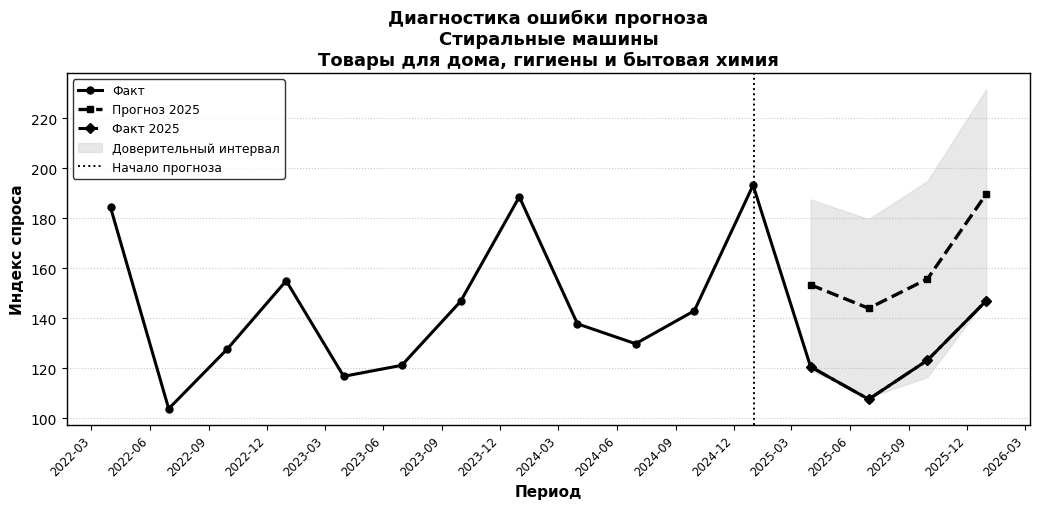

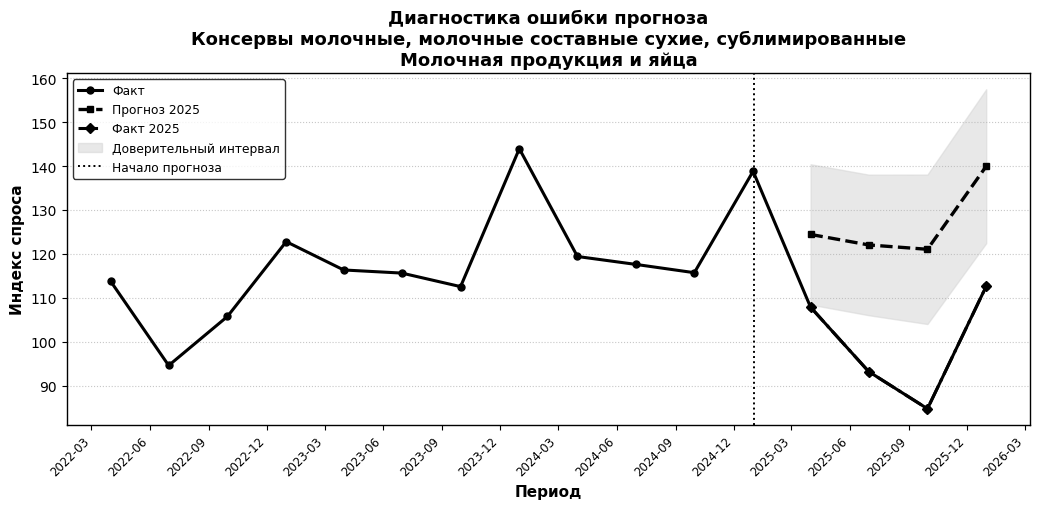

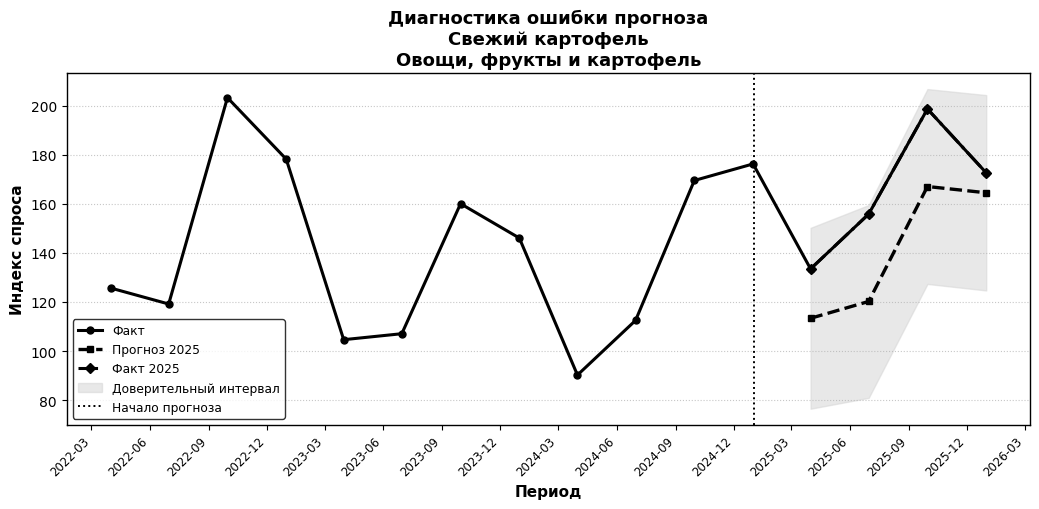

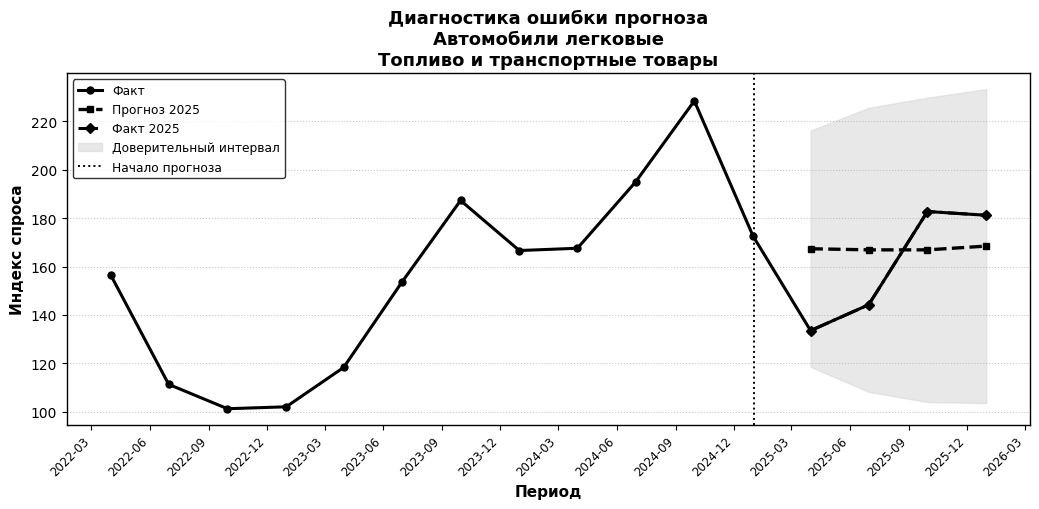

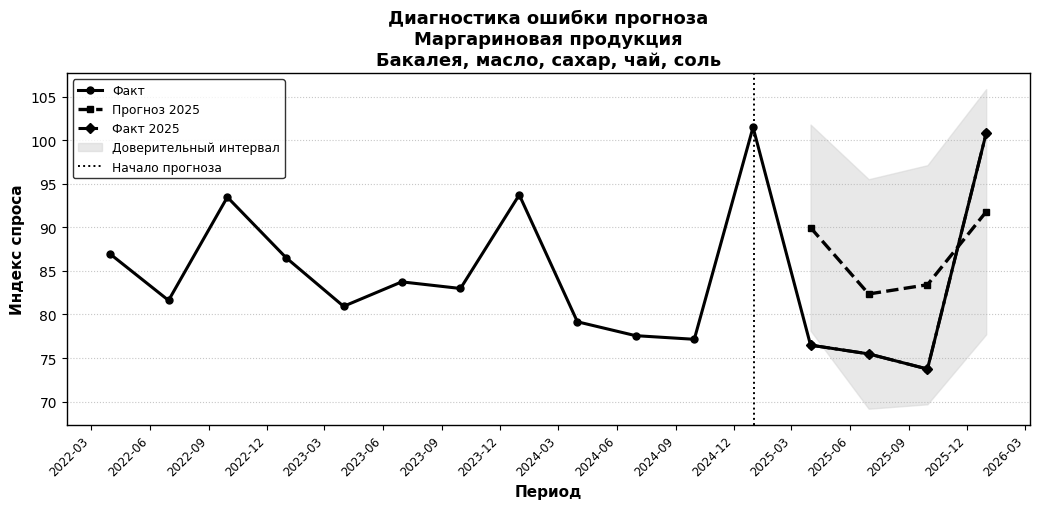

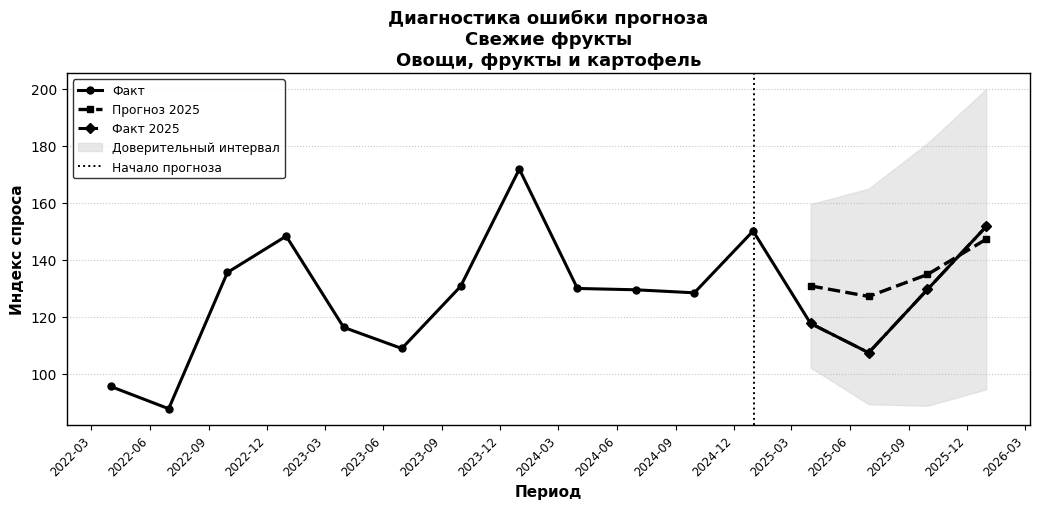

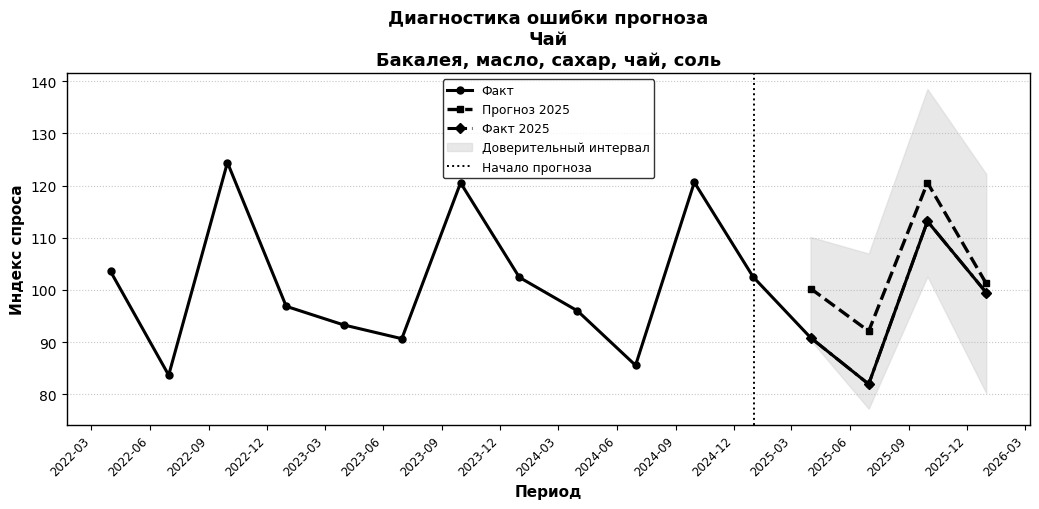

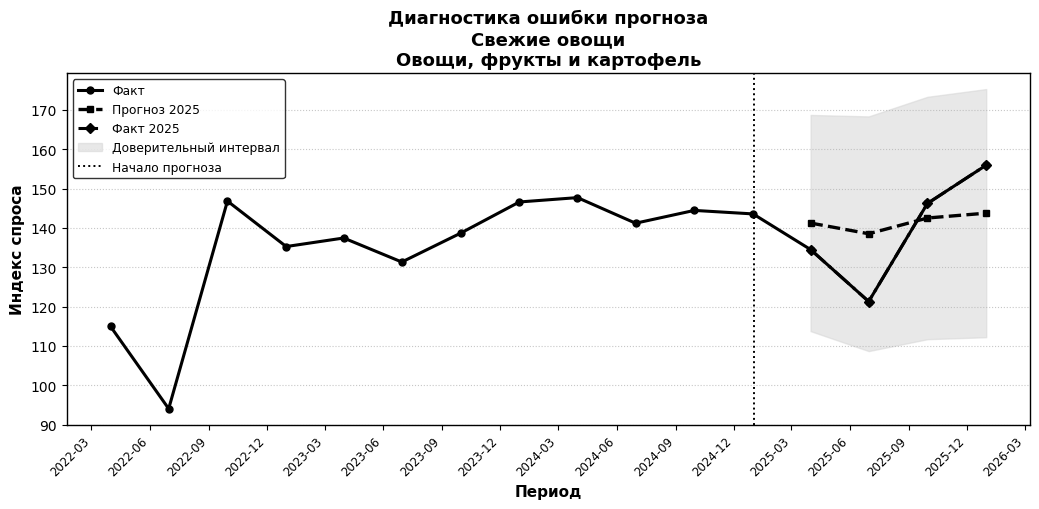

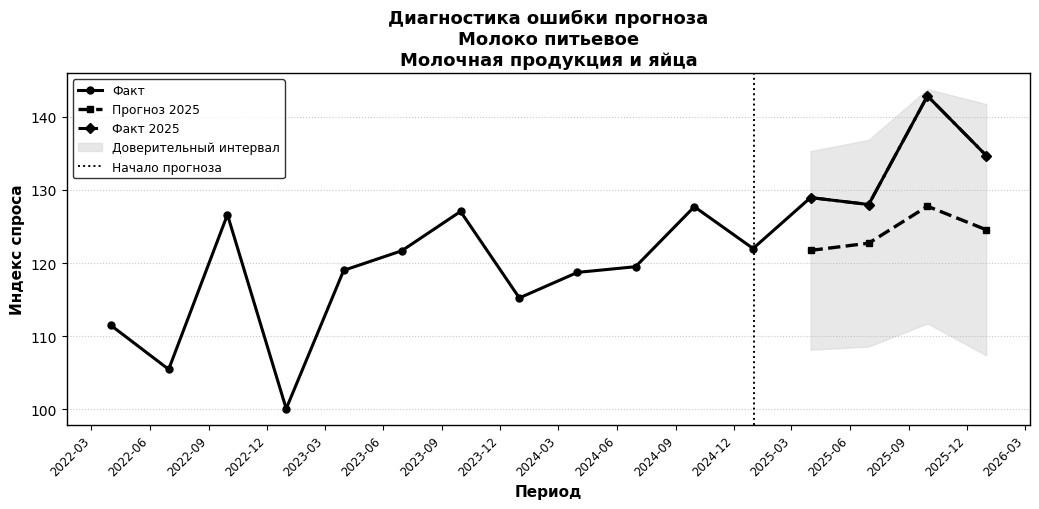

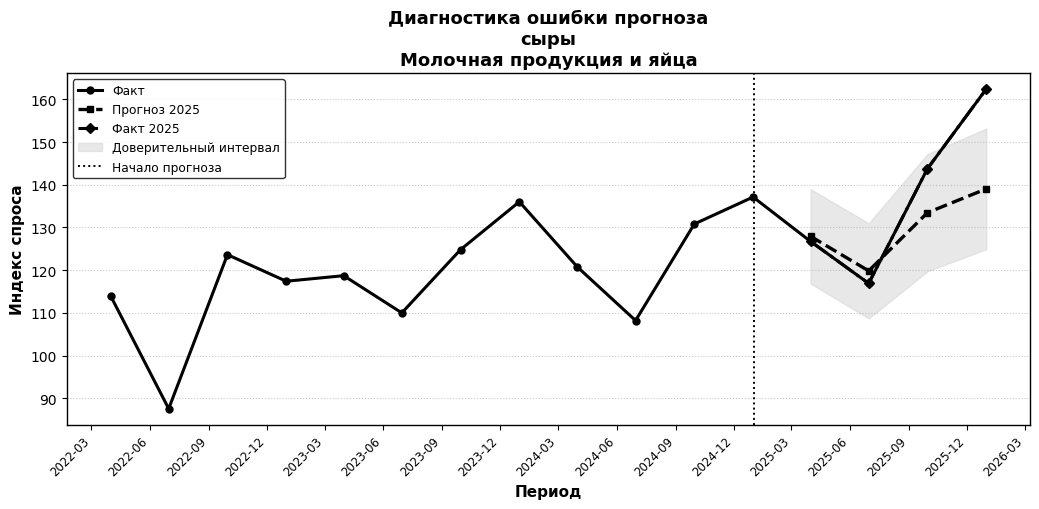

In [48]:
# ============================================================
# 8. Графики проблемных товаров
# ============================================================

bad_products = (
    product_error_diagnostic
    .sort_values("wape_percent", ascending=False)
    .head(10)["product_name"]
    .tolist()
)

for product_name in bad_products:

    hist = df[df["product_name"] == product_name].copy()
    hist["period_end"] = pd.to_datetime(hist["period_end"])
    hist = hist.sort_values("period_end")

    fc = diagnostic[diagnostic["product_name"] == product_name].copy()
    fc["period_end"] = pd.to_datetime(fc["period_end"])
    fc = fc.sort_values("period_end")

    group_name = hist["group_name"].dropna().iloc[0] if "group_name" in hist.columns and hist["group_name"].notna().any() else ""

    hist_plot = hist[
        (hist["period_end"] >= pd.Timestamp("2022-01-01"))
        & (hist["period_end"] <= pd.Timestamp("2025-12-31"))
    ].copy()

    fig, ax = plt.subplots(figsize=(10.5, 5.2))

    ax.plot(
        hist_plot["period_end"],
        hist_plot["target_demand_index"],
        color="black",
        linestyle="-",
        linewidth=2.2,
        marker="o",
        markersize=5,
        label="Факт"
    )

    ax.plot(
        fc["period_end"],
        fc["forecast_target_demand_index"],
        color="black",
        linestyle="--",
        linewidth=2.4,
        marker="s",
        markersize=5,
        label="Прогноз 2025"
    )

    ax.plot(
        fc["period_end"],
        fc["actual_target_demand_index"],
        color="black",
        linestyle="-.",
        linewidth=2.2,
        marker="D",
        markersize=5,
        label="Факт 2025"
    )

    if {"forecast_lower", "forecast_upper"}.issubset(fc.columns):
        ax.fill_between(
            fc["period_end"],
            fc["forecast_lower"],
            fc["forecast_upper"],
            color="lightgray",
            alpha=0.5,
            label="Доверительный интервал"
        )

    ax.axvline(
        pd.Timestamp("2025-01-01"),
        color="black",
        linestyle=":",
        linewidth=1.4,
        label="Начало прогноза"
    )

    ax.set_title(
        f"Диагностика ошибки прогноза\n{product_name}\n{group_name}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Период", fontsize=11, fontweight="bold")
    ax.set_ylabel("Индекс спроса", fontsize=11, fontweight="bold")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8.5)

    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.7)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color("black")

    ax.legend(
        fontsize=8.8,
        frameon=True,
        edgecolor="black",
        loc="best"
    )

    plt.tight_layout()
    plt.show()

In [49]:
# ============================================================
# 9. Краткая диагностическая таблица причин
# ============================================================

diagnosis_summary = product_error_diagnostic.copy()

diagnosis_summary["main_issue"] = np.select(
    [
        diagnosis_summary["mape_percent"] < 10,
        diagnosis_summary["mean_error"] > 0,
        diagnosis_summary["mean_error"] < 0,
    ],
    [
        "ошибка невысокая",
        "модель систематически завышает спрос",
        "модель систематически занижает спрос",
    ],
    default="смешанная ошибка"
)

diagnosis_summary = diagnosis_summary[
    [
        "group_code",
        "group_name",
        "product_name",
        "observations",
        "actual_mean",
        "forecast_mean",
        "mean_error",
        "mape_percent",
        "wape_percent",
        "share_of_category_error_%",
        "main_issue",
    ]
].sort_values(
    ["group_code", "share_of_category_error_%"],
    ascending=[True, False]
)

display(diagnosis_summary)

,group_code,group_name,product_name,observations,actual_mean,forecast_mean,mean_error,mape_percent,wape_percent,share_of_category_error_%,main_issue
1,G01,"Хлеб, крупы, мука и макаронные изделия",Мука,4,104.534597,103.622588,-0.912009,3.996835,4.250633,51.493563,ошибка невысокая
0,G01,"Хлеб, крупы, мука и макаронные изделия",Макаронные изделия,4,117.147975,116.920896,-0.227079,3.788656,3.572936,48.506437,ошибка невысокая
2,G02,Молочная продукция и яйца,"Консервы молочные, молочные составные сухие, с...",4,99.608519,126.860852,27.252333,28.343682,27.359441,59.059296,модель систематически завышает спрос
4,G02,Молочная продукция и яйца,сыры,4,137.457934,130.070472,-7.387462,6.254342,6.877972,20.488718,ошибка невысокая
3,G02,Молочная продукция и яйца,Молоко питьевое,4,133.626459,124.189091,-9.437369,6.957592,7.062500,20.451986,ошибка невысокая
5,G03,"Мясо, птица, рыба и колбасные изделия",Мясо домашней птицы,4,118.327815,122.559240,4.231425,3.559173,3.576019,59.847868,ошибка невысокая
6,G03,"Мясо, птица, рыба и колбасные изделия",Мясо животных,4,102.404635,102.913585,0.508950,2.748243,2.772215,40.152132,ошибка невысокая
9,G04,"Овощи, фрукты и картофель",Свежий картофель,4,165.181015,141.294657,-23.886358,14.646184,14.460716,53.666962,модель систематически занижает спрос
8,G04,"Овощи, фрукты и картофель",Свежие фрукты,4,126.639351,135.066433,8.427082,9.138318,8.415442,23.944329,ошибка невысокая
7,G04,"Овощи, фрукты и картофель",Свежие овощи,4,139.493243,141.507918,2.014675,7.390054,7.143627,22.388708,ошибка невысокая


In [56]:
# ============================================================
# Вклад признаков SARIMAX без дублирующихся признаков
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore")


# ============================================================
# 1. Пути и настройки
# ============================================================

DATASET_DIR = Path.cwd() / "dataset"
DATA_PATH = DATASET_DIR / "demand_primary_training_minimal.csv"

OUT_FEATURE_PRODUCT = DATASET_DIR / "sarimax_feature_contribution_clean_by_product.csv"
OUT_FEATURE_GROUP = DATASET_DIR / "sarimax_feature_contribution_clean_by_group.csv"
OUT_FEATURE_TOTAL = DATASET_DIR / "sarimax_feature_contribution_clean_total.csv"

TARGET_COL = "target_demand_index"

TRAIN_END = pd.Period("2024Q4", freq="Q")

ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 0, 1, 4)

MIN_OBSERVATIONS = 12


# ============================================================
# 2. Загрузка данных
# ============================================================

df = pd.read_csv(DATA_PATH)

df["period_end"] = pd.to_datetime(df["period_end"])
df["period"] = df["period_end"].dt.to_period("Q")

df = df.rename(columns={
    "sales_product_code": "product_code",
    "sales_product_name": "product_name",
    "product_group_name": "group_name",
})

df = df.sort_values(["product_name", "period"])


# ============================================================
# 3. Очищенный набор признаков
# ============================================================
# Берем только базовые факторы, без групповых дублей.
# sales_index и sales_quarter_thousand_rub не берем,
# потому что target_demand_index уже построен на основе продаж.

EXOG_COLS = [
    "consumer_price_index",
    "income_index",
    "stock_days_mean",
    "stock_value_mean_thousand_rub",
]

EXOG_COLS = [col for col in EXOG_COLS if col in df.columns]

print("Признаки для расчета вклада:")
for col in EXOG_COLS:
    print("-", col)


# ============================================================
# 4. Функции
# ============================================================

def fill_exog(exog_df):
    exog_df = exog_df.copy()
    exog_df = exog_df.astype(float)
    exog_df = exog_df.ffill().bfill()
    exog_df = exog_df.fillna(exog_df.median())
    exog_df = exog_df.fillna(0)
    return exog_df


def fit_model(y_train, exog_train):
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    return model.fit(disp=False)


def get_exog_params(fitted, exog_cols):
    params = fitted.params.copy()

    found = {}

    for col in exog_cols:
        if col in params.index:
            found[col] = params[col]

    if len(found) == len(exog_cols):
        return pd.Series(found)

    # запасной вариант, если statsmodels назвал признаки x1, x2 и т.д.
    return pd.Series(
        params.iloc[:len(exog_cols)].values,
        index=exog_cols
    )


# ============================================================
# 5. Обучение моделей и расчет вклада
# ============================================================

feature_rows = []

for product_name, product_df in df.groupby("product_name"):

    product_df = product_df.sort_values("period").copy()
    product_df = product_df.set_index("period")

    y_all = product_df[TARGET_COL].astype(float).sort_index()
    exog_all = product_df[EXOG_COLS].sort_index()

    y_train_raw = y_all[y_all.index <= TRAIN_END].dropna()

    if len(y_train_raw) < MIN_OBSERVATIONS:
        print(f"Пропуск: {product_name} — мало наблюдений")
        continue

    first_train_period = y_train_raw.index.min()
    last_train_period = y_train_raw.index.max()

    train_periods_full = pd.period_range(
        first_train_period,
        last_train_period,
        freq="Q"
    )

    y_train = y_all.reindex(train_periods_full)

    exog_train_raw = exog_all.reindex(train_periods_full)
    exog_train_filled = fill_exog(exog_train_raw)

    scaler = StandardScaler()

    exog_train_scaled = pd.DataFrame(
        scaler.fit_transform(exog_train_filled),
        index=exog_train_filled.index,
        columns=exog_train_filled.columns
    )

    try:
        fitted = fit_model(y_train, exog_train_scaled)

        exog_params = get_exog_params(fitted, EXOG_COLS)

        contribution_matrix = exog_train_scaled.mul(
            exog_params,
            axis=1
        )

        total_abs_contribution = (
            contribution_matrix
            .abs()
            .sum()
            .sum()
        )

        group_code = (
            product_df["group_code"].dropna().iloc[0]
            if "group_code" in product_df.columns and product_df["group_code"].notna().any()
            else None
        )

        group_name = (
            product_df["group_name"].dropna().iloc[0]
            if "group_name" in product_df.columns and product_df["group_name"].notna().any()
            else None
        )

        for feature in EXOG_COLS:

            feature_abs_sum = contribution_matrix[feature].abs().sum()

            feature_rows.append({
                "product_name": product_name,
                "group_code": group_code,
                "group_name": group_name,
                "train_start": str(first_train_period),
                "train_end": str(last_train_period),
                "observations": int(y_train.notna().sum()),
                "feature": feature,
                "coef": exog_params[feature],
                "mean_abs_contribution": contribution_matrix[feature].abs().mean(),
                "mean_signed_contribution": contribution_matrix[feature].mean(),
                "max_abs_contribution": contribution_matrix[feature].abs().max(),
                "share_of_exog_contribution_%": (
                    feature_abs_sum / total_abs_contribution * 100
                    if total_abs_contribution != 0
                    else np.nan
                ),
                "aic": fitted.aic,
                "bic": fitted.bic,
            })

    except Exception as e:
        print(f"Ошибка модели: {product_name}: {e}")


feature_contribution_product = pd.DataFrame(feature_rows)


# ============================================================
# 6. Сводка по группам
# ============================================================

feature_contribution_group = (
    feature_contribution_product
    .groupby(["group_code", "group_name", "feature"], as_index=False)
    .agg(
        products_count=("product_name", "nunique"),
        mean_coef=("coef", "mean"),
        mean_abs_contribution=("mean_abs_contribution", "mean"),
        mean_signed_contribution=("mean_signed_contribution", "mean"),
        max_abs_contribution=("max_abs_contribution", "max"),
        mean_share_of_exog_contribution_pct=("share_of_exog_contribution_%", "mean"),
    )
    .sort_values(["group_code", "mean_abs_contribution"], ascending=[True, False])
)


# ============================================================
# 7. Общая сводка по всем товарам
# ============================================================

feature_contribution_total = (
    feature_contribution_product
    .groupby("feature", as_index=False)
    .agg(
        products_count=("product_name", "nunique"),
        mean_coef=("coef", "mean"),
        mean_abs_contribution=("mean_abs_contribution", "mean"),
        mean_signed_contribution=("mean_signed_contribution", "mean"),
        max_abs_contribution=("max_abs_contribution", "max"),
        mean_share_of_exog_contribution_pct=("share_of_exog_contribution_%", "mean"),
    )
    .sort_values("mean_abs_contribution", ascending=False)
)


# ============================================================
# 8. Сохранение и вывод
# ============================================================

feature_contribution_product.to_csv(
    OUT_FEATURE_PRODUCT,
    index=False,
    encoding="utf-8-sig"
)

feature_contribution_group.to_csv(
    OUT_FEATURE_GROUP,
    index=False,
    encoding="utf-8-sig"
)

feature_contribution_total.to_csv(
    OUT_FEATURE_TOTAL,
    index=False,
    encoding="utf-8-sig"
)

print("Сохранено:")
print(OUT_FEATURE_PRODUCT)
print(OUT_FEATURE_GROUP)
print(OUT_FEATURE_TOTAL)

display(feature_contribution_total)
display(feature_contribution_group)
display(feature_contribution_product.head(30))

Признаки для расчета вклада:
- consumer_price_index
- income_index
- stock_days_mean
- stock_value_mean_thousand_rub
Сохранено:
/home/senya/projects/diplom/dataset/sarimax_feature_contribution_clean_by_product.csv
/home/senya/projects/diplom/dataset/sarimax_feature_contribution_clean_by_group.csv
/home/senya/projects/diplom/dataset/sarimax_feature_contribution_clean_total.csv


,feature,products_count,mean_coef,mean_abs_contribution,mean_signed_contribution,max_abs_contribution,mean_share_of_exog_contribution_pct
3,stock_value_mean_thousand_rub,19,26.712799,25.208036,-3.898752e-15,233.683382,42.340904
0,consumer_price_index,19,-21.934924,19.696942,-9.294113e-15,139.520685,28.654366
1,income_index,19,5.806189,8.567258,-1.629966e-15,98.796405,20.024799
2,stock_days_mean,19,-4.860309,4.407693,-8.171653e-15,59.734024,8.979931


,group_code,group_name,feature,products_count,mean_coef,mean_abs_contribution,mean_signed_contribution,max_abs_contribution,mean_share_of_exog_contribution_pct
3,G01,"Хлеб, крупы, мука и макаронные изделия",stock_value_mean_thousand_rub,2,17.002479,14.918844,-3.996803e-15,50.339606,43.495858
0,G01,"Хлеб, крупы, мука и макаронные изделия",consumer_price_index,2,-11.023035,9.866284,-1.303124e-14,28.842609,24.324413
1,G01,"Хлеб, крупы, мука и макаронные изделия",income_index,2,8.473020,6.770051,-3.441691e-15,33.332284,21.725466
2,G01,"Хлеб, крупы, мука и макаронные изделия",stock_days_mean,2,-1.620730,2.312822,-3.365364e-15,11.197460,10.454264
7,G02,Молочная продукция и яйца,stock_value_mean_thousand_rub,4,28.929874,26.408894,-6.786238e-15,124.963883,55.675941
4,G02,Молочная продукция и яйца,consumer_price_index,4,-9.239175,8.497008,5.429684e-15,45.020100,15.328314
5,G02,Молочная продукция и яйца,income_index,4,3.411147,2.725550,-1.280226e-15,16.121111,23.788807
6,G02,Молочная продукция и яйца,stock_days_mean,4,-0.036995,0.943923,-8.456777e-17,5.889683,5.206938
8,G03,"Мясо, птица, рыба и колбасные изделия",consumer_price_index,2,-30.563053,26.740845,-7.549517e-15,100.559154,44.813037
11,G03,"Мясо, птица, рыба и колбасные изделия",stock_value_mean_thousand_rub,2,20.985912,18.414111,-5.107026e-15,47.422533,39.639135


,product_name,group_code,group_name,train_start,train_end,observations,feature,coef,mean_abs_contribution,mean_signed_contribution,max_abs_contribution,share_of_exog_contribution_%,aic,bic
0,Автомобили легковые,G10,Топливо и транспортные товары,2017Q1,2024Q4,32,consumer_price_index,-69.756189,61.993901,6.572520e-14,139.520685,29.867907,231.424031,242.393914
1,Автомобили легковые,G10,Топливо и транспортные товары,2017Q1,2024Q4,32,income_index,-31.816731,25.421974,1.376677e-14,98.796405,12.247998,231.424031,242.393914
2,Автомобили легковые,G10,Топливо и транспортные товары,2017Q1,2024Q4,32,stock_days_mean,-23.760094,19.395868,-4.773959e-14,59.734024,9.344693,231.424031,242.393914
3,Автомобили легковые,G10,Топливо и транспортные товары,2017Q1,2024Q4,32,stock_value_mean_thousand_rub,114.819507,100.748504,-2.309264e-14,233.683382,48.539402,231.424031,242.393914
4,Бензины автомобильные,G10,Топливо и транспортные товары,2017Q1,2024Q1,21,consumer_price_index,-2.211435,1.904849,5.727219e-15,6.051463,7.029861,81.805357,91.624739
5,Бензины автомобильные,G10,Топливо и транспортные товары,2017Q1,2024Q1,21,income_index,-4.654842,4.211923,6.064115e-15,8.687531,15.544134,81.805357,91.624739
6,Бензины автомобильные,G10,Топливо и транспортные товары,2017Q1,2024Q1,21,stock_days_mean,-9.245014,7.453955,-4.992175e-15,25.287277,27.508879,81.805357,91.624739
7,Бензины автомобильные,G10,Топливо и транспортные товары,2017Q1,2024Q1,21,stock_value_mean_thousand_rub,15.031956,13.525815,-1.127068e-14,25.826667,49.917126,81.805357,91.624739
8,Газовое моторное топливо,G10,Топливо и транспортные товары,2017Q1,2024Q1,25,consumer_price_index,-63.138852,56.193732,-1.063364e-13,123.788236,40.601376,167.167319,176.986701
9,Газовое моторное топливо,G10,Топливо и транспортные товары,2017Q1,2024Q1,25,income_index,26.081020,22.140414,-7.105427e-15,44.851513,15.997003,167.167319,176.986701


In [57]:
top_features_by_group = (
    feature_contribution_group
    .sort_values(
        ["group_code", "mean_abs_contribution"],
        ascending=[True, False]
    )
    .groupby(["group_code", "group_name"])
    .head(3)
    .reset_index(drop=True)
)

display(top_features_by_group)

,group_code,group_name,feature,products_count,mean_coef,mean_abs_contribution,mean_signed_contribution,max_abs_contribution,mean_share_of_exog_contribution_pct
0,G01,"Хлеб, крупы, мука и макаронные изделия",stock_value_mean_thousand_rub,2,17.002479,14.918844,-3.996803e-15,50.339606,43.495858
1,G01,"Хлеб, крупы, мука и макаронные изделия",consumer_price_index,2,-11.023035,9.866284,-1.303124e-14,28.842609,24.324413
2,G01,"Хлеб, крупы, мука и макаронные изделия",income_index,2,8.473020,6.770051,-3.441691e-15,33.332284,21.725466
3,G02,Молочная продукция и яйца,stock_value_mean_thousand_rub,4,28.929874,26.408894,-6.786238e-15,124.963883,55.675941
4,G02,Молочная продукция и яйца,consumer_price_index,4,-9.239175,8.497008,5.429684e-15,45.020100,15.328314
5,G02,Молочная продукция и яйца,income_index,4,3.411147,2.725550,-1.280226e-15,16.121111,23.788807
6,G03,"Мясо, птица, рыба и колбасные изделия",consumer_price_index,2,-30.563053,26.740845,-7.549517e-15,100.559154,44.813037
7,G03,"Мясо, птица, рыба и колбасные изделия",stock_value_mean_thousand_rub,2,20.985912,18.414111,-5.107026e-15,47.422533,39.639135
8,G03,"Мясо, птица, рыба и колбасные изделия",income_index,2,11.091455,9.533152,-4.274359e-15,71.489180,12.338301
9,G04,"Овощи, фрукты и картофель",stock_value_mean_thousand_rub,3,26.760883,23.481367,-5.847175e-15,110.477913,40.607907
